# NaCl：短程拟合、长程回加与 Phonopy NAC 声子谱

本教程只演示一条完整流程：**扣除 Ewald 长程力 → 拟合剩余力 → 回加长程 FC2 → 导出 → Phonopy NAC**。
拟合 cutoff 固定为 11 Å，不再循环多个 cutoff 或封装绘图 helper。

数据来自 [hiPhive 官方长程示例](https://hiphive.materialsmodeling.org/advanced_topics/long_range_forces.html)，
原始文件及 MIT 许可证保存在 `data/nacl`。两帧是 Phonopy 位移力样本，原子顺序必须与其超胞一致。
本教程不需要安装 hiPhive。

MLFCS 的 `DipoleEwald` 提供零宏观电场下的周期长程 FC2；**NAC 和任意 q 的长程插值由 Phonopy 完成**。
MLFCS 自己的 `Harmonic.run_band_path` 目前不做 NAC。

## 1. 准备 Phonopy 几何和 Born 数据

原始结构是 8 原子常规胞；通过明确的 FCC primitive matrix 得到 2 原子原胞。
MLFCS 原胞、超胞均从同一个 Phonopy 对象取得，保证导出的 FC2 原子顺序与 Phonopy 一致。
`BORN` 的 Born 电荷按该原胞顺序展开，第一轴为极化、第二轴为位移；介电张量使用笛卡尔坐标。
使用 ASE 的 Coulomb 换算因子，与 Ewald 的 eV、Å 单位一致。

In [1]:
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms, units
from ase.io import read
from phonopy import Phonopy
from phonopy.file_IO import parse_BORN, read_force_constants_hdf5
from phonopy.structure.atoms import PhonopyAtoms

from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem, CompactForceConstants
from mlfcs.phonon import DipoleEwald

DATA = Path("data") / "nacl"
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-nacl-"))
unitcell = read(DATA / "NaCl_unitcell.xyz")
structures = read(DATA / "supercells_with_forces.xyz", index=":")
phonon = Phonopy(
    PhonopyAtoms(
        symbols=unitcell.get_chemical_symbols(),
        cell=unitcell.cell.array,
        scaled_positions=unitcell.get_scaled_positions(),
        masses=unitcell.get_masses(),
    ),
    supercell_matrix=np.diag([4, 4, 4]),
    primitive_matrix=[[0, .5, .5], [.5, 0, .5], [.5, .5, 0]],
)
primitive_atoms = Atoms(
    numbers=phonon.primitive.numbers, positions=phonon.primitive.positions,
    cell=phonon.primitive.cell, masses=phonon.primitive.masses, pbc=True,
)
supercell_atoms = Atoms(
    numbers=phonon.supercell.numbers, positions=phonon.supercell.positions,
    cell=phonon.supercell.cell, masses=phonon.supercell.masses, pbc=True,
)
nac = parse_BORN(phonon.primitive, filename=str(DATA / "BORN"))
nac["factor"] = units.Hartree * units.Bohr
print(f"primitive={len(primitive_atoms)}, supercell={len(supercell_atoms)}, frames={len(structures)}")
print("Born charges:\n", nac["born"])
print("dielectric:\n", nac["dielectric"])

primitive=2, supercell=512, frames=2
Born charges:
 [[[ 1.09328000e+00  7.31516009e-34  1.82960072e-34]
  [-5.48555937e-34  1.09328000e+00 -1.82960072e-34]
  [ 0.00000000e+00  0.00000000e+00  1.09328000e+00]]

 [[-1.09328000e+00 -7.31516009e-34 -1.82960072e-34]
  [ 5.48555937e-34 -1.09328000e+00  1.82960072e-34]
  [ 0.00000000e+00  0.00000000e+00 -1.09328000e+00]]]
dielectric:
 [[2.419776 0.       0.      ]
 [0.       2.419776 0.      ]
 [0.       0.       2.419776]]


## 2. 扣除长程力并拟合短程

`ForceDataset` 读取已有力，不启动 calculator。`subtract_forces` 返回新数据集；
原始数据不变。这里 raw 方程使用 LSMR，其列归一化在求解器内部完成。
ASR 作用于短程模型；Ewald 输出自身已处理 onsite 和局域修正。
拟合残差针对扣除后的剩余力，不是总力常数或声子频率的误差。

In [2]:
space = ClusterSpace(primitive_atoms, cutoffs={2: 11.0})
mapping = ClusterMap(space, supercell_atoms)
data = ForceDataset(mapping, structures)
ewald = DipoleEwald(mapping, born_charges=nac["born"], dielectric=nac["dielectric"])
short_data = data.subtract_forces(ewald.forces(data.displacements))

system = FitSystem(short_data, representation="raw")
short_model = system.solve().enforce_asr().force_constants
print(f"FC2 parameters: {space.n_parameters}")
print(f"short-range force RMSE: {system.rmse(short_model):.6e} eV/Å")

2026-10-07 19:25:01 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=2 orders=(2,) symprec=1e-05


2026-10-07 19:25:01 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=48 symbol=Fm-3m


2026-10-07 19:25:01 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=11 max_body_order=2


2026-10-07 19:25:01 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=502


2026-10-07 19:25:01 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=23 parameters=76 elapsed_s=0.26


...

2026-10-07 19:25:52 INFO mlfcs.fitting.system: Fit complete: training_force_rmse=1.48360406836e-05 eV/angstrom training_relative_force_error=0.02299536 elapsed_s=0.00


2026-10-07 19:25:52 INFO mlfcs.force_constants.asr: ASR projection started: orders=(2,) rtol=1e-10


2026-10-07 19:25:52 INFO mlfcs.force_constants.asr: ASR order complete: order=2 equations=18 iterations=2 relative_before=5.39201e-05 relative_after=7.6917e-18 correction_norm=0.000678959


2026-10-07 19:25:52 INFO mlfcs.force_constants.asr: ASR projection complete: orders=(2,) elapsed_s=0.02


FC2 parameters: 76
short-range force RMSE: 1.484340e-05 eV/Å


## 3. 合并张量并写出 Phonopy FC2

短程模型与 Ewald 都通过 `CompactForceConstants` 表达，可直接相加。
写出 HDF5 时 MLFCS 分块生成 full FC2；Phonopy 读文件时会物化完整数组。
这里只写一份**短程加长程总 FC2**，不把短程 FC2 单独当作 NAC 的输入。

In [3]:
total = CompactForceConstants(short_model, mapping) + ewald.force_constants()
fc2_file = SCRATCH / "force_constants.hdf5"
total.write(fc2_file, format="phonopy", order=2, storage="hdf5", threshold=0)
phonon.force_constants = read_force_constants_hdf5(str(fc2_file))
print(f"exported FC2: {phonon.force_constants.shape}")

2026-10-07 19:25:52 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-nacl-rn6lcuch/force_constants.hdf5 format=phonopy order=2 storage=hdf5 threshold=0


2026-10-07 19:25:55 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-nacl-rn6lcuch/force_constants.hdf5 format=phonopy order=2 elapsed_s=3.01


exported FC2: (512, 512, 3, 3)


## 4. 设置 NAC 并沿 Γ–X–L–Γ 计算

**启用 NAC 的关键就是设置 `phonon.nac_params`**：Born、介电和单位换算必须与长程扣除时一致。
这里选择 Phonopy 的 Gonze 方法：它从周期 FC2 中分离长程贡献，再按 q 补回长程插值；
不能在已经回加的总 FC2 上再手动叠加一份 Ewald。

ASE 只负责给出模型原胞基底中的高对称点。每条直线分别传给 Phonopy，
它按该线段方向处理 Γ 点极限；相同 Γ 点在不同方向上的频率可能不同，所以不能把端点去重。

In [4]:
special_points = primitive_atoms.cell.bandpath(npoints=0).special_points
labels = ("G", "X", "L", "G")
paths = [
    np.linspace(special_points[start], special_points[stop], 67)
    for start, stop in zip(labels[:-1], labels[1:])
]

# Same total FC2, first without NAC and then with NAC.
phonon.nac_params = None
phonon.run_band_structure(paths)
without_nac = phonon.band_structure

phonon.nac_params = {**nac, "method": "gonze"}
phonon.run_band_structure(paths)
with_nac = phonon.band_structure
print("Gamma -> X frequencies without NAC:", np.round(without_nac.frequencies[0][0], 5), "THz")
print("Gamma -> X frequencies with NAC:   ", np.round(with_nac.frequencies[0][0], 5), "THz")

Gamma -> X frequencies without NAC: [-0.      -0.      -0.       4.34527  4.34527  4.34527] THz
Gamma -> X frequencies with NAC:    [-0.      -0.      -0.       4.34527  4.34527  7.27241] THz


## 5. 画 NAC 前后的声子谱

曲线按直线段分别绘制，保留每段自己的 Γ 极限；不把不同方向的 Γ 频率连成竖线。
该图展示 NAC 的作用，不是实验精度验证。局域修正依赖拟合 cutoff，
实际研究仍需检查训练残差以及改变 cutoff、超胞大小后的总声子谱收敛。

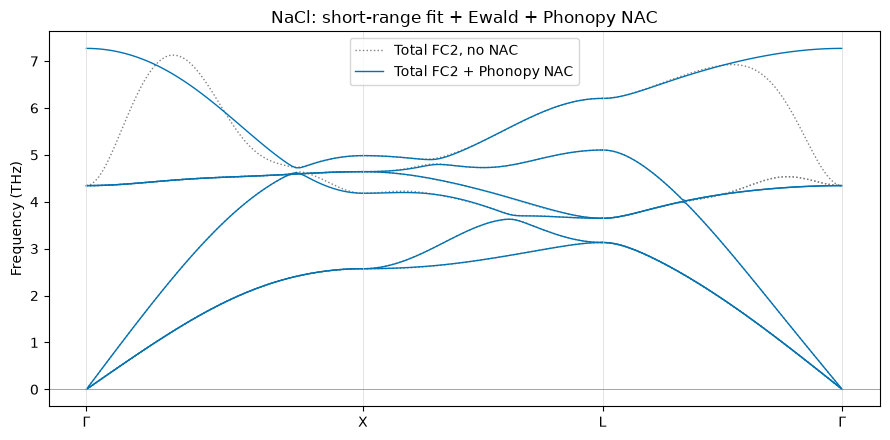

In [5]:
fig, axis = plt.subplots(figsize=(9, 4.5))
for band, color, style, label in (
    (without_nac, "0.5", ":", "Total FC2, no NAC"),
    (with_nac, "#0072B2", "-", "Total FC2 + Phonopy NAC"),
):
    for index, (distance, frequencies) in enumerate(zip(band.distances, band.frequencies)):
        lines = axis.plot(distance, frequencies, color=color, linestyle=style, linewidth=1)
        if index == 0:
            lines[0].set_label(label)
ticks = [with_nac.distances[0][0]] + [distance[-1] for distance in with_nac.distances]
axis.set_xticks(ticks, ["Γ", "X", "L", "Γ"])
for tick in ticks:
    axis.axvline(tick, color="0.85", linewidth=0.5)
axis.axhline(0, color="0.5", linewidth=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("NaCl: short-range fit + Ewald + Phonopy NAC")
axis.legend()
fig.tight_layout()
plt.show()

## 使用边界

- Ewald 是固定参考 Born/介电的谐波模型，不是构型依赖的点电荷势。
- 在有限超胞内扣除与回加使用同一 Ewald；任意 q 的 NAC 插值由外部 Phonopy 处理。
- 原子顺序和 Born 原胞顺序都必须一致；本例从 Phonopy 取得几何来保证这一点。
- 原生 `short_model.save(...)` 只保存短程参数模型，不保存 Ewald 配方。
- 本例只示范 FC2 和声子谱，不计算热导率。

接口细节见[数据集与 Ewald](../dataset-api.md)，
NAC 物理定义与方法见 [Phonopy formulations](https://phonopy.github.io/phonopy/formulation.html#non-analytical-term-correction)。